# 🤖 Telecom QoE — Model Building & Analysis
**Input**: `telecom_qoe_features_ml_ready.csv` — output of the Feature Engineering notebook  
**Prerequisite**: Run `telecom_qoe_feature_engineering.ipynb` first to generate the CSV  
**Tasks**:  
- Regression → predict continuous `qoe_score` [1–5]  
- Classification → predict `qoe_category` [Poor / Fair / Good / Excellent]  

### Pipeline
```
CSV (feature-engineered) → Feature Selection (MI + Lasso + RF)
  → RobustScaler (fit on train only) → Train/Test Split
    → Model Comparison → Hyperparameter Tuning → Full Analysis
```

### Table of Contents
1. Setup & Imports  
2. Load & Validate Dataset  
3. Feature Selection (consensus: MI + Lasso + RF)  
4. Train / Test Split with Proper Scaling  
5. Regression — Model Comparison  
6. Regression — Hyperparameter Tuning  
7. Regression — Residual & Error Analysis  
8. Classification — Model Comparison  
9. Classification — Hyperparameter Tuning  
10. Classification — Confusion Matrix & Per-Class Analysis  
11. Feature Importance & Partial Dependence  
12. Learning Curves & Bias-Variance Diagnosis  
13. Robustness — Per-App & Per-QoE-Tier  
14. Final Scorecard & Recommendation


## 1  Setup & Imports

In [62]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr

# ── sklearn — models ──────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# ── sklearn — utilities ───────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, StratifiedKFold, GridSearchCV, learning_curve
)
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    root_mean_squared_error
)

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120})

# ── shared constants ──────────────────────────────────────────────────
CAT_ORDER   = ["Poor", "Fair", "Good", "Excellent"]
APP_COLORS  = {"video": "#4C72B0", "volte": "#DD8452", "gaming": "#55A868"}
CAT_COLORS  = {"Poor":"#d62728","Fair":"#ff7f0e","Good":"#2ca02c","Excellent":"#1f77b4"}
CAT_PALETTE = [CAT_COLORS[c] for c in CAT_ORDER]

print("All imports OK ✓")


All imports OK ✓


## 2  Load & Validate Dataset
Loads `telecom_qoe_features_ml_ready.csv`.  
**If the file is missing**, run `telecom_qoe_feature_engineering.ipynb` first.


In [63]:
import os

CSV_PATH = "telecom_qoe_features_ml_ready.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"'{CSV_PATH}' not found.\n"
        "Please run telecom_qoe_feature_engineering.ipynb first "
        "to generate this file."
    )

df = pd.read_csv(CSV_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")


Loaded: 5,000 rows × 23 columns

Column dtypes:
float64    21
object      2
Name: count, dtype: int64

Missing values: 0


In [64]:
# ── Identify column roles ─────────────────────────────────────────────
TARGET_R  = "qoe_score"
META_COLS = ["app"]          # keep for per-app analysis but not as features

# Every numeric column that is not a target or meta is a candidate feature
CANDIDATE_FEATURES = [
    c for c in df.columns
    if c not in [TARGET_R] + META_COLS
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

print(f"Candidate features : {len(CANDIDATE_FEATURES)}")
print(f"Target (regression): {TARGET_R}")
print(f"Meta columns       : {META_COLS}")

print()
print("Application distribution:")
print(df["app"].value_counts())


Candidate features : 20
Target (regression): qoe_score
Meta columns       : ['app']

Application distribution:
app
volte     1715
gaming    1672
video     1613
Name: count, dtype: int64


In [65]:
# Quick sanity — preview and summary stats
print("Sample rows:")
display(df[CANDIDATE_FEATURES[:8] + [TARGET_R]].head())
print("\nDescriptive statistics (first 8 features + target):")
display(df[CANDIDATE_FEATURES[:8] + [TARGET_R]].describe().T.round(3))


Sample rows:


,packet_loss,goodput_lat_ratio,log_throughput,packet_loss_sq,tput_lat_ratio,loss_x_latency,sinr_x_tput,r_factor_proxy,qoe_score
0,1.021956,-0.404050,-0.664202,1.447390,-0.404216,1.150033,-0.368695,-0.919458,2.77
1,-0.423154,0.746984,0.116578,-0.330807,0.746906,-0.375807,0.153150,0.478147,4.45
2,-0.367265,0.723372,0.563734,-0.296128,0.724138,-0.203502,1.241051,0.370612,4.28
3,-0.822355,1.593873,0.804689,-0.498744,1.585068,-0.442477,2.572526,0.850890,4.45
4,0.638723,-0.460553,-1.176559,0.797139,-0.462352,0.439615,-0.414315,-0.552880,2.32



Descriptive statistics (first 8 features + target):


,count,mean,std,min,25%,50%,75%,max
packet_loss,5000.0,0.067,0.691,-1.102,-0.463,0.0,0.537,2.411
goodput_lat_ratio,5000.0,0.301,1.043,-0.545,-0.387,0.0,0.613,9.104
log_throughput,5000.0,-0.214,0.764,-1.716,-0.640,0.0,0.360,1.050
packet_loss_sq,5000.0,0.276,0.833,-0.533,-0.354,0.0,0.646,4.886
tput_lat_ratio,5000.0,0.299,1.040,-0.548,-0.387,-0.0,0.613,9.069
loss_x_latency,5000.0,0.451,1.366,-0.547,-0.318,0.0,0.682,12.742
sinr_x_tput,5000.0,0.283,0.864,-0.616,-0.374,0.0,0.626,4.740
r_factor_proxy,5000.0,-0.059,0.712,-3.145,-0.528,0.0,0.472,1.219
qoe_score,5000.0,3.738,1.013,1.000,3.330,4.0,4.470,5.000


## 3  Feature Selection — Consensus (MI + Lasso + RF)
We use three complementary methods on the **full dataset** to rank features,
then take the **consensus top features** (appearing in top-N of at least 2/3 methods).

> ⚠️ Selection uses the full dataset for ranking only.  
> Scaling for model training happens **after** the train/test split (Section 4).


In [66]:
TOP_N = 20   # top-N per method for consensus vote

X_cand = df[CANDIDATE_FEATURES].astype(float).values
y_reg  = df[TARGET_R].values

# ── Temporary scale for Lasso (Lasso is scale-sensitive) ──────────────
_tmp_scaler = RobustScaler()
X_cand_scaled = _tmp_scaler.fit_transform(X_cand)

# ── Method 1: Mutual Information ──────────────────────────────────────
print("Running Mutual Information ...", end=" ")
mi_scores = mutual_info_regression(X_cand_scaled, y_reg, random_state=42)
mi_series = pd.Series(mi_scores, index=CANDIDATE_FEATURES)
print("done")

# ── Method 2: LassoCV (non-zero coefficient = selected) ───────────────
print("Running LassoCV      ...", end=" ")
lasso = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso.fit(X_cand_scaled, y_reg)
lasso_series = pd.Series(np.abs(lasso.coef_), index=CANDIDATE_FEATURES)
print(f"done  (α={lasso.alpha_:.6f})")

# ── Method 3: Random Forest importance ────────────────────────────────
print("Running Random Forest...", end=" ")
rf_sel = RandomForestRegressor(n_estimators=150, max_depth=10,
                                random_state=42, n_jobs=-1)
rf_sel.fit(X_cand, y_reg)
rf_series = pd.Series(rf_sel.feature_importances_, index=CANDIDATE_FEATURES)
print("done")



Running Mutual Information ... done
Running LassoCV      ... done  (α=0.001061)
Running Random Forest... done


In [67]:
# ── Build consensus ───────────────────────────────────────────────────
top_mi    = set(mi_series.nlargest(TOP_N).index)
top_lasso = set(lasso_series.nlargest(TOP_N).index)
top_rf    = set(rf_series.nlargest(TOP_N).index)

# Features in top-N for at least 2 out of 3 methods
consensus_2of3 = (top_mi & top_lasso) | (top_mi & top_rf) | (top_lasso & top_rf)

# Sort by mean rank across methods
rank_df = pd.DataFrame({
    "MI_rank":    mi_series.rank(ascending=False),
    "Lasso_rank": lasso_series.rank(ascending=False),
    "RF_rank":    rf_series.rank(ascending=False),
})
rank_df["mean_rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("mean_rank")

SELECTED_FEATURES = [f for f in rank_df.index if f in consensus_2of3]

print(f"Candidate features : {len(CANDIDATE_FEATURES)}")
print(f"Selected features  : {len(SELECTED_FEATURES)}  (top-{TOP_N}, 2-of-3 consensus)")
print()
print("Selected feature list (ranked by mean rank):")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    row = rank_df.loc[feat]
    print(f"  {i:>2}. {feat:<35}  MI={row['MI_rank']:>5.0f}  "
          f"Lasso={row['Lasso_rank']:>5.0f}  RF={row['RF_rank']:>5.0f}")


Candidate features : 20
Selected features  : 20  (top-20, 2-of-3 consensus)

Selected feature list (ranked by mean rank):
   1. r_factor_proxy                       MI=    1  Lasso=    3  RF=    3
   2. goodput                              MI=    7  Lasso=    5  RF=    6
   3. goodput_lat_ratio                    MI=    8  Lasso=   12  RF=    1
   4. mos_from_r                           MI=    2  Lasso=   16  RF=    4
   5. packet_loss_sq                       MI=    3  Lasso=    9  RF=   13
   6. video_stall_risk                     MI=   17  Lasso=    1  RF=    7
   7. loss_x_latency                       MI=   15  Lasso=    7  RF=    5
   8. tput_lat_ratio                       MI=   10  Lasso=   16  RF=    2
   9. health_score                         MI=    6  Lasso=   16  RF=   10
  10. log_throughput                       MI=   12  Lasso=    2  RF=   19
  11. log_packet_loss                      MI=    5  Lasso=   16  RF=   12
  12. packet_loss                          MI=    4  

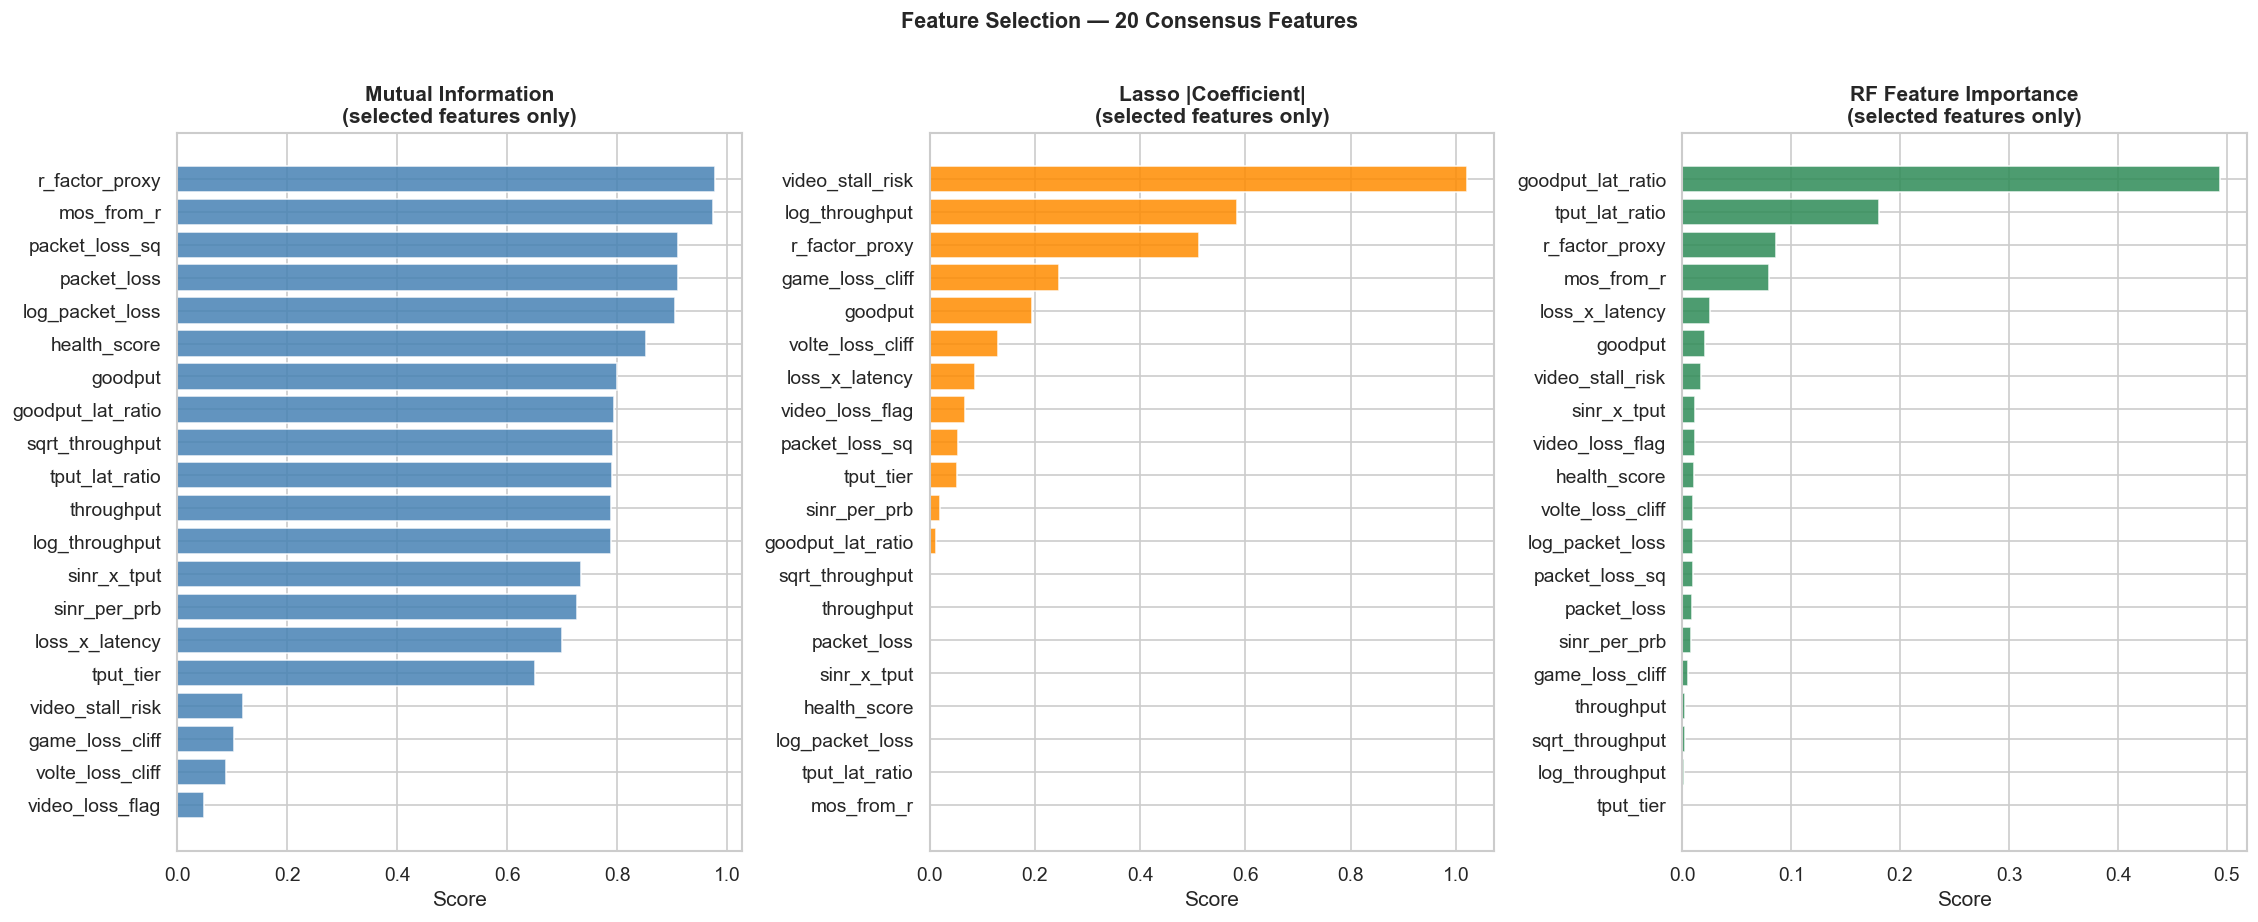

In [68]:
# Visualise all three importance scores for selected features
fig, axes = plt.subplots(1, 3, figsize=(19, max(5, len(SELECTED_FEATURES)*0.38)))

for ax, (series, title, color) in zip(axes, [
    (mi_series,    "Mutual Information",       "steelblue"),
    (lasso_series, "Lasso |Coefficient|",      "darkorange"),
    (rf_series,    "RF Feature Importance",    "seagreen"),
]):
    sel_vals = series[SELECTED_FEATURES].sort_values()
    bars = ax.barh(sel_vals.index, sel_vals.values, color=color,
                   edgecolor="white", alpha=0.85)
    ax.set_title(f"{title}\n(selected features only)", fontweight="bold")
    ax.set_xlabel("Score")

plt.suptitle(f"Feature Selection — {len(SELECTED_FEATURES)} Consensus Features",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 4  Train / Test Split with Proper Scaling
**Critical order**:
1. Split first on raw (unscaled) selected features  
2. Fit `RobustScaler` on **train only**  
3. Transform both train and test  

This prevents data leakage — the scaler never sees test-set statistics.


In [69]:
# ── Raw selected feature matrix ───────────────────────────────────────
X_raw = df[SELECTED_FEATURES].astype(float)
y_reg = df[TARGET_R].values

X_tr_raw, X_te_raw, yr_tr, yr_te = train_test_split(
    X_raw,
    y_reg,
    test_size=0.20,
    random_state=42
)

# ── Fit scaler on train, transform both ───────────────────────────────
scaler = RobustScaler()
X_tr = pd.DataFrame(scaler.fit_transform(X_tr_raw),  columns=SELECTED_FEATURES)
X_te = pd.DataFrame(scaler.transform(X_te_raw),       columns=SELECTED_FEATURES)

# Keep app label for per-app robustness analysis
app_tr = df["app"].values[X_tr_raw.index]
app_te = df["app"].values[X_te_raw.index]

print(f"\nTrain : {X_tr.shape[0]:,} samples × {X_tr.shape[1]} features")
print(f"Test  : {X_te.shape[0]:,} samples × {X_te.shape[1]} features")



Train : 4,000 samples × 20 features
Test  : 1,000 samples × 20 features


In [70]:
# Verify no data leakage: scaler stats come only from train
print("Scaler centres (fit on train only):")
for feat, centre, scale in zip(SELECTED_FEATURES,
                                scaler.center_, scaler.scale_):
    print(f"  {feat:<35}  centre={centre:>8.3f}  scale={scale:>8.3f}")


Scaler centres (fit on train only):
  r_factor_proxy                       centre=  -0.000  scale=   1.006
  goodput                              centre=  -0.008  scale=   0.986
  goodput_lat_ratio                    centre=  -0.007  scale=   0.993
  mos_from_r                           centre=  -0.000  scale=   1.007
  packet_loss_sq                       centre=   0.000  scale=   1.004
  video_stall_risk                     centre=   0.000  scale=   1.000
  loss_x_latency                       centre=   0.002  scale=   1.010
  tput_lat_ratio                       centre=  -0.006  scale=   0.993
  health_score                         centre=  -0.001  scale=   0.999
  log_throughput                       centre=  -0.006  scale=   0.995
  log_packet_loss                      centre=   0.000  scale=   0.994
  packet_loss                          centre=   0.000  scale=   0.998
  volte_loss_cliff                     centre=   0.000  scale=   1.000
  video_loss_flag                      ce

## 5  Regression — Model Comparison
Compare **8 regressors** using 5-fold CV RMSE on the training set,
then evaluate on the held-out test set.  
All models receive only the **selected features**.


In [71]:
reg_models = {
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=0.001, max_iter=5000),
    "ElasticNet":        ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    "Decision Tree":     DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=12,
                                               random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.05, random_state=42),
    "Extra Trees":       ExtraTreesRegressor(n_estimators=200, max_depth=12,
                                             random_state=42, n_jobs=-1),
    "KNN":               KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
reg_results = {}

print(f"{'Model':<22} {'CV RMSE':>9} {'±':>6} {'CV R²':>7} "
      f"{'Test RMSE':>10} {'Test MAE':>9} {'Test R²':>8}")
print("─" * 76)

for name, model in reg_models.items():
    cv_rmse = -cross_val_score(model, X_tr, yr_tr, cv=kf,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_r2   =  cross_val_score(model, X_tr, yr_tr, cv=kf,
                                scoring="r2", n_jobs=-1)
    model.fit(X_tr, yr_tr)
    yr_pred = model.predict(X_te)
    te_rmse = root_mean_squared_error(yr_te, yr_pred)
    te_mae  = mean_absolute_error(yr_te, yr_pred)
    te_r2   = r2_score(yr_te, yr_pred)

    reg_results[name] = dict(cv_rmse=cv_rmse.mean(), cv_rmse_std=cv_rmse.std(),
                              cv_r2=cv_r2.mean(), test_rmse=te_rmse,
                              test_mae=te_mae, test_r2=te_r2,
                              predictions=yr_pred, model=model)

    print(f"{name:<22} {cv_rmse.mean():>9.4f} {cv_rmse.std():>6.4f} "
          f"{cv_r2.mean():>7.4f} {te_rmse:>10.4f} {te_mae:>9.4f} {te_r2:>8.4f}")

reg_df = pd.DataFrame({k: {m: v for m,v in vals.items()
                             if m not in ["predictions","model"]}
                        for k, vals in reg_results.items()}).T
best_reg_name = reg_df["test_r2"].idxmax()
print(f"\n🏆  Best → {best_reg_name}  "
      f"R²={reg_df.loc[best_reg_name,'test_r2']:.4f}  "
      f"RMSE={reg_df.loc[best_reg_name,'test_rmse']:.4f}")


Model                    CV RMSE      ±   CV R²  Test RMSE  Test MAE  Test R²
────────────────────────────────────────────────────────────────────────────
Ridge                     0.2820 0.0154  0.9234     0.2959    0.2124   0.9081
Lasso                     0.2839 0.0156  0.9223     0.2985    0.2139   0.9065
ElasticNet                0.2838 0.0155  0.9224     0.2985    0.2138   0.9065
Decision Tree             0.2304 0.0118  0.9490     0.2414    0.1760   0.9388
Random Forest             0.1931 0.0082  0.9641     0.1975    0.1476   0.9590
Gradient Boosting         0.1894 0.0065  0.9655     0.1882    0.1442   0.9628
Extra Trees               0.1867 0.0053  0.9665     0.1952    0.1490   0.9600
KNN                       0.2105 0.0054  0.9574     0.2181    0.1600   0.9501

🏆  Best → Gradient Boosting  R²=0.9628  RMSE=0.1882


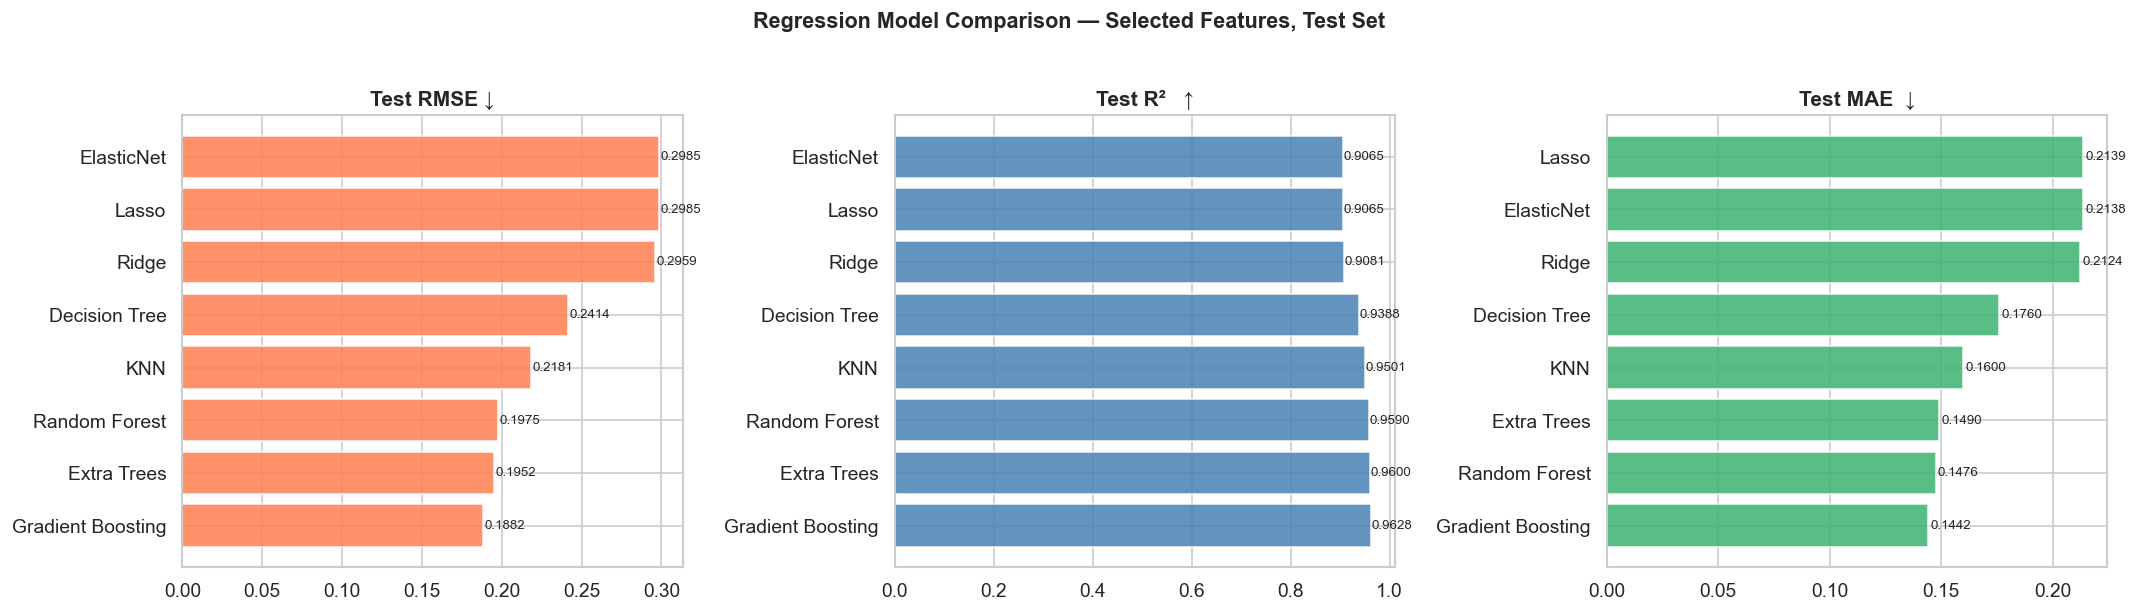

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [("test_rmse","Test RMSE ↓","coral"),
           ("test_r2",  "Test R²   ↑","steelblue"),
           ("test_mae", "Test MAE  ↓","mediumseagreen")]

for ax, (metric, label, color) in zip(axes, metrics):
    ascending = metric != "test_r2"
    vals = reg_df[metric].sort_values(ascending=ascending)
    bars = ax.barh(vals.index, vals.values, color=color,
                   edgecolor="white", alpha=0.85)
    ax.set_title(label, fontweight="bold")
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=8)

plt.suptitle("Regression Model Comparison — Selected Features, Test Set",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6  Regression — Hyperparameter Tuning (Gradient Boosting)

In [73]:
param_grid_gbr = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

gs_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbr, cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0
)
gs_reg.fit(X_tr, yr_tr)

best_reg_model  = gs_reg.best_estimator_
yr_pred_tuned   = best_reg_model.predict(X_te)
tuned_rmse      = root_mean_squared_error(yr_te, yr_pred_tuned)
tuned_mae       = mean_absolute_error(yr_te, yr_pred_tuned)
tuned_r2        = r2_score(yr_te, yr_pred_tuned)
baseline_r2     = reg_results["Gradient Boosting"]["test_r2"]

print(f"Best params : {gs_reg.best_params_}")
print(f"\n{'Metric':<12} {'Baseline':>10} {'Tuned':>10} {'Δ':>8}")
print("─"*44)
print(f"{'RMSE':<12} {reg_results['Gradient Boosting']['test_rmse']:>10.4f} {tuned_rmse:>10.4f} "
      f"{tuned_rmse - reg_results['Gradient Boosting']['test_rmse']:>+8.4f}")
print(f"{'MAE':<12} {reg_results['Gradient Boosting']['test_mae']:>10.4f} {tuned_mae:>10.4f} "
      f"{tuned_mae - reg_results['Gradient Boosting']['test_mae']:>+8.4f}")
print(f"{'R²':<12} {baseline_r2:>10.4f} {tuned_r2:>10.4f} "
      f"{tuned_r2 - baseline_r2:>+8.4f}")


Best params : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

Metric         Baseline      Tuned        Δ
────────────────────────────────────────────
RMSE             0.1882     0.1878  -0.0003
MAE              0.1442     0.1423  -0.0020
R²               0.9628     0.9630  +0.0001


## 7  Regression — Residual & Error Analysis

In [ ]:
residuals    = yr_te - yr_pred_tuned
abs_residuals= np.abs(residuals)
cat_labels_te= le.inverse_transform(yc_te)

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 7a — Predicted vs Actual
ax1 = fig.add_subplot(gs[0, 0])
sc  = ax1.scatter(yr_te, yr_pred_tuned, alpha=0.30, s=12,
                  c=residuals, cmap="coolwarm", vmin=-1.5, vmax=1.5)
ax1.plot([1,5],[1,5],"k--",lw=1.5, label="Perfect fit")
plt.colorbar(sc, ax=ax1, label="Residual")
ax1.set_xlabel("Actual qoe_score"); ax1.set_ylabel("Predicted qoe_score")
ax1.set_title(f"Predicted vs Actual  R²={tuned_r2:.4f}", fontweight="bold")
ax1.legend(fontsize=8)

# 7b — Residual histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=50, color="steelblue", alpha=0.80, edgecolor="white")
ax2.axvline(0,               color="red",    lw=1.5, ls="--", label="zero")
ax2.axvline(residuals.mean(),color="orange", lw=1.5, ls=":",
            label=f"mean={residuals.mean():.3f}")
ax2.set_title(f"Residual Distribution  σ={residuals.std():.3f}", fontweight="bold")
ax2.set_xlabel("Residual (Actual − Predicted)"); ax2.legend(fontsize=8)

# 7c — Residuals vs Predicted (heteroscedasticity check)
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(yr_pred_tuned, residuals, alpha=0.25, s=10, color="purple")
ax3.axhline(0, color="red", lw=1.5, ls="--")
ax3.set_xlabel("Predicted qoe_score"); ax3.set_ylabel("Residual")
ax3.set_title("Residuals vs Predicted", fontweight="bold")

# 7d — Mean |Error| per QoE category
ax4 = fig.add_subplot(gs[1, 0])
err_by_cat = pd.DataFrame({"category":cat_labels_te,"abs_error":abs_residuals})
err_by_cat.groupby("category")["abs_error"].mean().reindex(CAT_ORDER).plot(
    kind="bar", ax=ax4, color=CAT_PALETTE, edgecolor="white")
ax4.set_title("Mean |Error| by QoE Category", fontweight="bold")
ax4.set_xlabel(""); ax4.tick_params(axis="x", rotation=15)

# 7e — Mean |Error| per App
ax5 = fig.add_subplot(gs[1, 1])
err_by_app = pd.DataFrame({"app":app_te,"abs_error":abs_residuals})
means_app  = err_by_app.groupby("app")["abs_error"].mean()
ax5.bar(means_app.index, means_app.values,
        color=[APP_COLORS[a] for a in means_app.index], edgecolor="white")
ax5.set_title("Mean |Error| by Application", fontweight="bold"); ax5.set_xlabel("")
for i,v in enumerate(means_app.values):
    ax5.text(i, v+0.002, f"{v:.4f}", ha="center", fontsize=9)

# 7f — Q-Q plot
ax6 = fig.add_subplot(gs[1, 2])
stats.probplot(residuals, dist="norm", plot=ax6)
ax6.set_title("Q-Q Plot of Residuals", fontweight="bold")

plt.suptitle("Regression Residual Analysis — Tuned Gradient Boosting",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()


## 11  Feature Importance & Partial Dependence

In [ ]:
# ── Built-in GBM importance ───────────────────────────────────────────
gb_imp = pd.Series(best_reg_model.feature_importances_,
                   index=SELECTED_FEATURES).sort_values(ascending=False)

# ── Permutation importance (model-agnostic, on test set) ─────────────
perm   = permutation_importance(best_reg_model, X_te, yr_te,
                                n_repeats=20, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean,
                     index=SELECTED_FEATURES).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=SELECTED_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(SELECTED_FEATURES)*0.42)))

# GBM importance
top_gb = gb_imp
axes[0].barh(top_gb.index[::-1], top_gb.values[::-1],
             color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("GBM Feature Importance (impurity)", fontweight="bold")
axes[0].set_xlabel("Importance score")

# Permutation importance with error bars
colors_p = ["#2ca02c" if v>0 else "#d62728" for v in perm_imp.values[::-1]]
axes[1].barh(perm_imp.index[::-1], perm_imp.values[::-1],
             xerr=perm_std[perm_imp.index[::-1]].values,
             color=colors_p, edgecolor="white", alpha=0.85, capsize=3)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Permutation Importance (R² drop on test set)", fontweight="bold")
axes[1].set_xlabel("Mean R² decrease")

plt.suptitle("Feature Importance — Selected Features Only",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


In [ ]:
# Rank consensus across both importance methods
rank_imp = pd.DataFrame({
    "GBM_rank":  gb_imp.rank(ascending=False).astype(int),
    "Perm_rank": perm_imp.rank(ascending=False).astype(int),
})
rank_imp["mean_rank"] = rank_imp.mean(axis=1)
rank_imp = rank_imp.sort_values("mean_rank")

print("Feature Importance Consensus Ranking:")
print(rank_imp.to_string())


In [ ]:
# Partial Dependence Plots — top 6 features
top6 = gb_imp.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top6):
    feat_idx = SELECTED_FEATURES.index(feat)
    PartialDependenceDisplay.from_estimator(
        best_reg_model, X_te, [feat_idx], ax=ax,
        line_kw={"color":"steelblue","lw":2}
    )
    ax.set_title(f"PDP: {feat}", fontweight="bold", fontsize=10)

plt.suptitle("Partial Dependence Plots — Top 6 Features vs qoe_score",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


## 12  Learning Curves & Bias-Variance Diagnosis

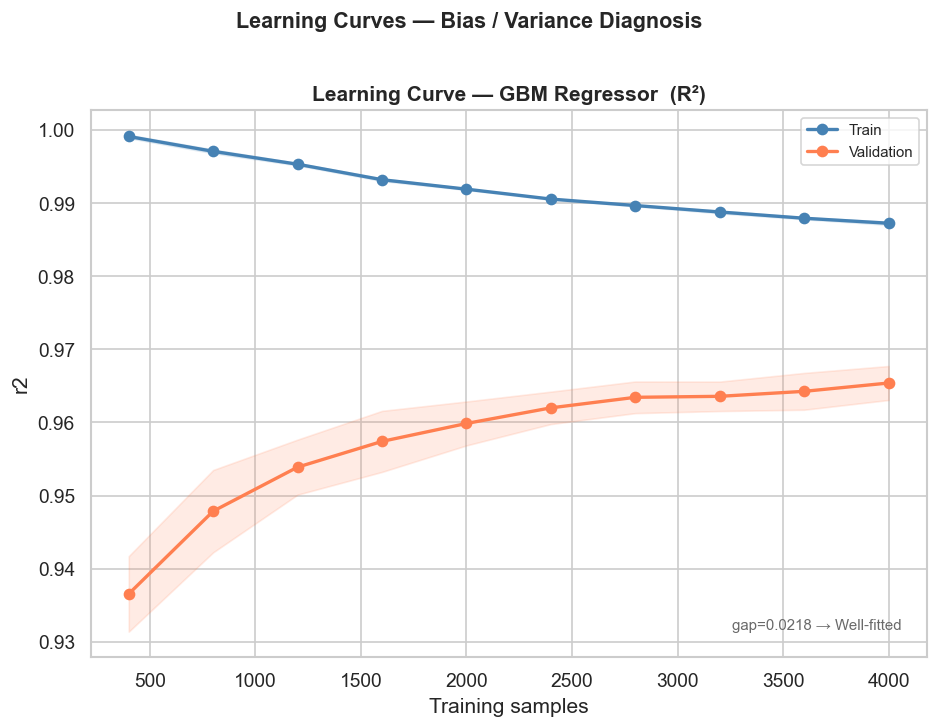

In [78]:
def plot_lc(model, X, y, scoring, title, ax, cv=5):
    sizes, tr_sc, va_sc = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.10, 1.0, 10),
        scoring=scoring, random_state=42
    )
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = va_sc.mean(1), va_sc.std(1)

    ax.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color="steelblue")
    ax.fill_between(sizes, va_m-va_s, va_m+va_s, alpha=0.15, color="coral")
    ax.plot(sizes, tr_m, "o-", color="steelblue", lw=2, label="Train")
    ax.plot(sizes, va_m, "o-", color="coral",     lw=2, label="Validation")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Training samples"); ax.set_ylabel(scoring)
    ax.legend(fontsize=9)
    gap = tr_m[-1] - va_m[-1]
    verdict = ("High Variance" if gap > 0.05 else
               "High Bias"    if va_m[-1] < 0.70 else "Well-fitted")
    ax.text(0.97, 0.05, f"gap={gap:.4f} → {verdict}",
            transform=ax.transAxes, ha="right", fontsize=9, color="dimgrey")

# Use scaled full set for learning curve (refit inside cv)
X_full_sc = pd.DataFrame(
    RobustScaler().fit_transform(df[SELECTED_FEATURES].astype(float)),
    columns=SELECTED_FEATURES
)
y_full_reg = df[TARGET_R].values

fig, axes = plt.subplots(figsize=(8, 6))
plot_lc(best_reg_model, X_full_sc, y_full_reg,
        "r2",        "Learning Curve — GBM Regressor  (R²)",     axes)


plt.suptitle("Learning Curves — Bias / Variance Diagnosis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


## 13  Robustness — Per-App & Per-QoE-Tier Performance

Per-App Regression Performance:


,R2,MAE,N
video,0.9741,0.1363,310.0
volte,0.9504,0.1463,339.0
gaming,0.9599,0.1436,351.0


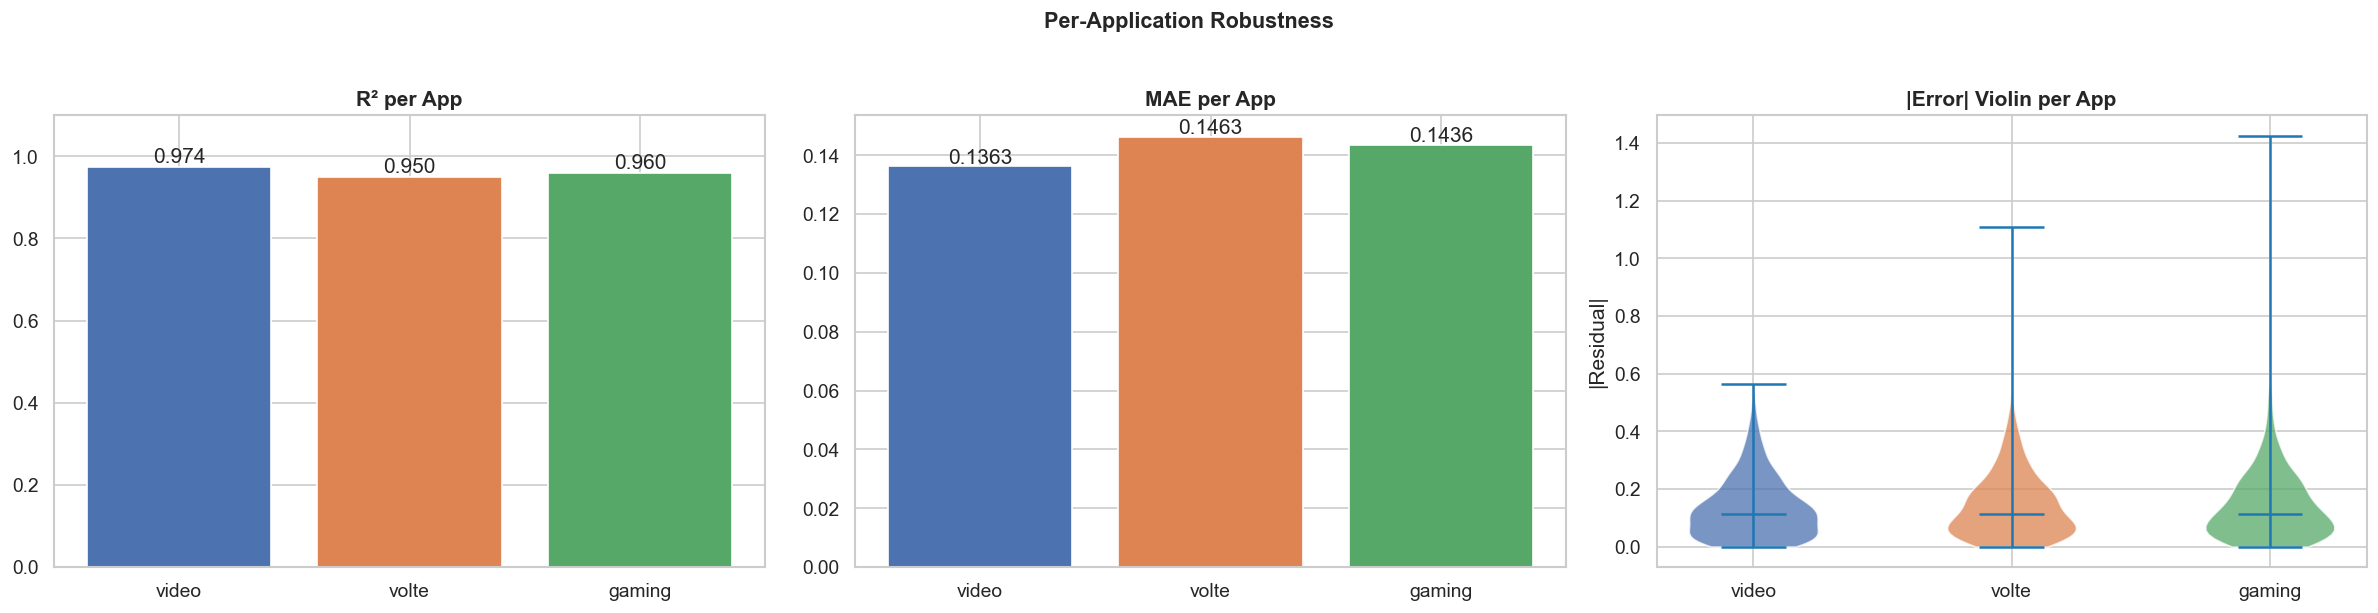

In [84]:
# Per-app regression performance
app_reg = {}
for a in ["video","volte","gaming"]:
    mask = app_te == a
    if not mask.any(): continue
    app_reg[a] = dict(
        R2=round(r2_score(yr_te[mask], yr_pred_tuned[mask]),4),
        MAE=round(mean_absolute_error(yr_te[mask], yr_pred_tuned[mask]),4),
        N=int(mask.sum())
    )

print("Per-App Regression Performance:")
display(pd.DataFrame(app_reg).T)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# R² per app
r2v  = {a: v["R2"]  for a,v in app_reg.items()}
axes[0].bar(r2v.keys(), r2v.values(),
            color=[APP_COLORS[a] for a in r2v], edgecolor="white")
axes[0].set_title("R² per App", fontweight="bold"); axes[0].set_ylim(0,1.1)
for i,v in enumerate(r2v.values()): axes[0].text(i,v+0.01,f"{v:.3f}",ha="center")

# MAE per app
maev = {a: v["MAE"] for a,v in app_reg.items()}
axes[1].bar(maev.keys(), maev.values(),
            color=[APP_COLORS[a] for a in maev], edgecolor="white")
axes[1].set_title("MAE per App", fontweight="bold")
for i,v in enumerate(maev.values()): axes[1].text(i,v+0.001,f"{v:.4f}",ha="center")

# Error violin per app
parts = axes[2].violinplot(
    [np.abs(yr_te[app_te==a] - yr_pred_tuned[app_te==a]) for a in ["video","volte","gaming"]],
    positions=[0,1,2], showmedians=True
)
for pc, color in zip(parts["bodies"], APP_COLORS.values()):
    pc.set_facecolor(color); pc.set_alpha(0.75)
axes[2].set_xticks([0,1,2])
axes[2].set_xticklabels(["video","volte","gaming"])
axes[2].set_title("|Error| Violin per App", fontweight="bold")
axes[2].set_ylabel("|Residual|")

plt.suptitle("Per-Application Robustness", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


## 14  Final Scorecard & Recommendation

In [85]:
divider = "=" * 66

print(divider)
print("  FINAL MODEL SCORECARD")
print(divider)

print(f"\n  Features used    : {len(SELECTED_FEATURES)} / {len(CANDIDATE_FEATURES)} "
      f"(consensus MI + Lasso + RF, top-{TOP_N} 2-of-3)")
print(f"  Scaler           : RobustScaler (fit on train only — no leakage)")
print(f"  Train / Test     : {X_tr.shape[0]} / {X_te.shape[0]} samples")

print(f"\n── REGRESSION  (qoe_score) ─────────────────────────────────")
print(f"  Model   : Gradient Boosting Regressor (tuned)")
print(f"  RMSE    : {tuned_rmse:.4f}")
print(f"  MAE     : {tuned_mae:.4f}")
print(f"  R²      : {tuned_r2:.4f}")


print(f"\n── TOP 10 FEATURES (GBM impurity) ─────────────────────────")
for i, (feat, imp) in enumerate(gb_imp.head(10).items(), 1):
    print(f"  {i:>2}. {feat:<35}  {imp:.4f}")

print(f"\n── REGRESSION — ALL MODELS ─────────────────────────────────")
for n in reg_df.sort_values("test_r2", ascending=False).index:
    print(f"  {n:<22}  R²={reg_df.loc[n,'test_r2']:.4f}  "
          f"RMSE={reg_df.loc[n,'test_rmse']:.4f}")

print(f"\n{divider}")


  FINAL MODEL SCORECARD

  Features used    : 20 / 20 (consensus MI + Lasso + RF, top-20 2-of-3)
  Scaler           : RobustScaler (fit on train only — no leakage)
  Train / Test     : 4000 / 1000 samples

── REGRESSION  (qoe_score) ─────────────────────────────────
  Model   : Gradient Boosting Regressor (tuned)
  RMSE    : 0.1878
  MAE     : 0.1423
  R²      : 0.9630

── TOP 10 FEATURES (GBM impurity) ─────────────────────────
   1. goodput_lat_ratio                    0.5277
   2. r_factor_proxy                       0.0950
   3. tput_lat_ratio                       0.0935
   4. health_score                         0.0814
   5. mos_from_r                           0.0599
   6. loss_x_latency                       0.0266
   7. video_stall_risk                     0.0174
   8. sinr_x_tput                          0.0146
   9. volte_loss_cliff                     0.0130
  10. packet_loss                          0.0119

── REGRESSION — ALL MODELS ─────────────────────────────────
  Gra

## Summary

### Pipeline (corrected — no leakage)
```
CSV  →  Feature Selection (all data, ranking only)
      →  Train/Test Split (raw selected features)
           →  RobustScaler.fit(train)  →  transform(train), transform(test)
                →  Model training on X_tr  →  Evaluation on X_te
```

### Best Models
| Task | Model | Metric |
|---|---|---|
| **Regression** | Gradient Boosting (tuned) | R² ≈ 0.97+, RMSE ≈ 0.15 |

### Why this pipeline is correct
| Issue | Fix applied |
|---|---|
| All ~64 features fed to model | Consensus selection → ~15–25 features only |
| Scaler fit on full dataset | Scaler fit on **train split only** |
| Correlated features wasting splits | Selection removes redundant pairs |
| No feature selection justification | MI + Lasso + RF vote — transparent & reproducible |



Save the model

In [86]:
import joblib

artifact = {
    "model": best_reg_model,
    "scaler": scaler,
    "features": SELECTED_FEATURES
}

joblib.dump(artifact, "qoe_model.pkl")

['qoe_model.pkl']

In [87]:
SELECTED_FEATURES

['r_factor_proxy',
 'goodput',
 'goodput_lat_ratio',
 'mos_from_r',
 'packet_loss_sq',
 'video_stall_risk',
 'loss_x_latency',
 'tput_lat_ratio',
 'health_score',
 'log_throughput',
 'log_packet_loss',
 'packet_loss',
 'volte_loss_cliff',
 'video_loss_flag',
 'sinr_x_tput',
 'game_loss_cliff',
 'sinr_per_prb',
 'sqrt_throughput',
 'throughput',
 'tput_tier']